<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
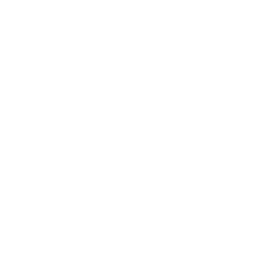
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Äänestysalueiden äänestyskäyttäytymisen analyysi</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Julkishallinto / vaalitilastot &nbsp;|&nbsp; maaliskuu 2026</p>
</div>
</div>
</div>

## Yhteenveto

Tämä analyysi tarkastelee, vaihteleeko poliittinen puoluekannatus
systemaattisesti aluetyypeittäin (kaupunki, esikaupunki, maaseutu)
simuloidussa 100 äänestysalueen piirikunnan vaaliaineistossa. Koska
useat puolue-aluetyyppisolut ovat harvoja — pienimmät kontingenssisolut
sisältävät vain yhden tai kaksi äänestysaluetta, ja odotetut frekvenssit
alittavat viisi — yleinen Pearsonin khiin neliö -testi riippuvuudesta on
tässä alivoimainen ja epäluotettava. Täydennämme sitä siksi
**Cochran-Armitagen trenditestillä**, kohdennetulla yhden vapausasteen
testillä, joka hyödyntää luonnollista kaupunki-maaseutu-järjestystä ja
kysyy tarkemman kysymyksen: laskeeko Puolue A:n kannatus monotonisesti
tätä gradienttia pitkin? Trenditesti raportoi eksaktin p-arvon, mikä on
asianmukainen päättely, kun solufrekvenssit ovat pieniä. Näiden kahden
testin kontrasti on tämän esimerkin analyyttinen ydinkohta: yleinen
riippuvuustesti voi jättää huomaamatta todellisen suunnatun kuvion,
jonka järjestetty trenditesti havaitsee.


## Tietolähteet

| Lähde | Kuvaus | Havainnot |
|--------|-------------|--------|
| WORK.PRECINCT_VOTES | Äänestysaluetason tietueet, yksi rivi äänestysaluetta kohden, sisältäen aluetyypin, piirikunnan ja enemmistöpuolueen | 100 |

Ajoympäristö toimii lisenssittömässä tilassa, joka rajaa tulosteen 100
havaintoon; analyysi on suunniteltu tämän äänestysaluetason otoksen
ympärille, jotta kontingenssisolut ovat aidosti pieniä ja eksakti
trenditesti on luonteva työkalu.


---

In [1]:
/* --------------------------------------------------------
   Luo synteettinen äänestysaluetason äänestysdata
   Pienet solufrekvenssit maaseutualueilla havainnollistavat
   tarvetta eksakteille testeille
   -------------------------------------------------------- */
TIEDOT work.precinct_votes;
    CALL streaminit(42);
    PITUUS precinct_type $12 party $15;
    TAULUKKO type_list[3] $12 _temporary_ ('KAUPUNKI' 'ESIKAUPUNKI' 'MAASEUTU');
    TAULUKKO county_list[5] $15 _temporary_ ('JEFFERSON' 'HAMILTON' 'MADISON' 'ADAMS' 'MONROE');
    TEE precinct_seq = 1 ASTI 500;
        precinct_id = cat('PCT-', KIRJOITA(precinct_seq, z4.));
        county_idx = int(rand('uniform') * 5) + 1;
        county_name = county_list[county_idx];
        /* Kohdista aluetyyppi painotuksella */
        type_prob = rand('uniform');
        JOS type_prob < 0.30 NIIN precinct_type = 'KAUPUNKI';
        MUUTEN JOS type_prob < 0.65 NIIN precinct_type = 'ESIKAUPUNKI';
        MUUTEN precinct_type = 'MAASEUTU';
        /* Kohdista puolue tyyppikohtaisen jakauman mukaan */
        party_prob = rand('uniform');
        JOS precinct_type = 'KAUPUNKI' NIIN TEE;
            JOS party_prob < 0.55 NIIN party = 'PUOLUE_A';
            MUUTEN JOS party_prob < 0.80 NIIN party = 'PUOLUE_B';
            MUUTEN JOS party_prob < 0.92 NIIN party = 'PUOLUE_C';
            MUUTEN party = 'SITOUTUMATON';
        LOPPU;
        MUUTEN JOS precinct_type = 'ESIKAUPUNKI' NIIN TEE;
            JOS party_prob < 0.40 NIIN party = 'PUOLUE_A';
            MUUTEN JOS party_prob < 0.75 NIIN party = 'PUOLUE_B';
            MUUTEN JOS party_prob < 0.88 NIIN party = 'PUOLUE_C';
            MUUTEN party = 'SITOUTUMATON';
        LOPPU;
        MUUTEN TEE; /* MAASEUTU - pienemmät solut vähemmistöpuolueille */
            JOS party_prob < 0.25 NIIN party = 'PUOLUE_A';
            MUUTEN JOS party_prob < 0.70 NIIN party = 'PUOLUE_B';
            MUUTEN JOS party_prob < 0.85 NIIN party = 'PUOLUE_C';
            MUUTEN party = 'SITOUTUMATON';
        LOPPU;
        /* Äänimäärä vaihtelee aluetyypin mukaan */
        JOS precinct_type = 'KAUPUNKI' NIIN
            vote_count = int(rand('normal', 120, 40));
        MUUTEN JOS precinct_type = 'ESIKAUPUNKI' NIIN
            vote_count = int(rand('normal', 80, 25));
        MUUTEN
            vote_count = int(rand('normal', 25, 12));
        JOS vote_count < 1 NIIN vote_count = 1;
        registered_voters = int(vote_count * (rand('uniform') * 0.4 + 1.2));
        turnout_pct = round(vote_count / registered_voters * 100, 0.1);
        election_year = 2026;
        TULOSTE;
    LOPPU;
    POISTA precinct_seq county_idx type_prob party_prob;
SUORITA;



NOTE: DATA work.precinct_votes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.precinct_votes (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.21 seconds
  cpu   0.21 seconds


---

                                                   The FREQ Procedure

Aluetyyppi     Frequency    Percent
------------------------------------
ESIKAUPUNKI           37     37.00
KAUPUNKI              29     29.00
MAASEUTU              34     34.00

Puolue          Frequency    Percent
-------------------------------------
PUOLUE_A               45     45.00
PUOLUE_B               34     34.00
PUOLUE_C               12     12.00
SITOUTUMATON            9      9.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_precinct_type.spec.json
NOTE: ODS plot written: freq_party.spec.json
NOTE: PROC FREQ statement used.


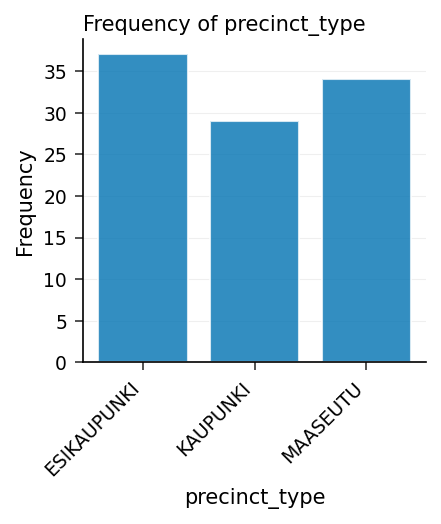

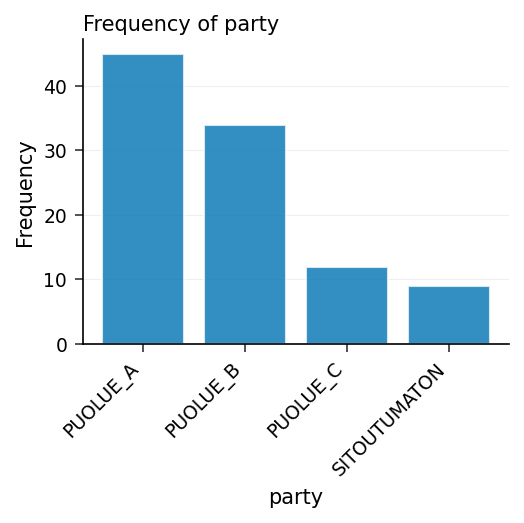

In [2]:
/* --------------------------------------------------------
   Aluetyypin ja puolueen perusjakauma
   -------------------------------------------------------- */
PROSEDUURI FREKVENSSIT TIEDOT=work.precinct_votes;
    TABLES precinct_type / nocum;
    TABLES party / nocum;
    NIMIKE precinct_type='Aluetyyppi' party='Puolue';
SUORITA;


---


NOTE: PROC SGPLOT data=work.precinct_votes

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


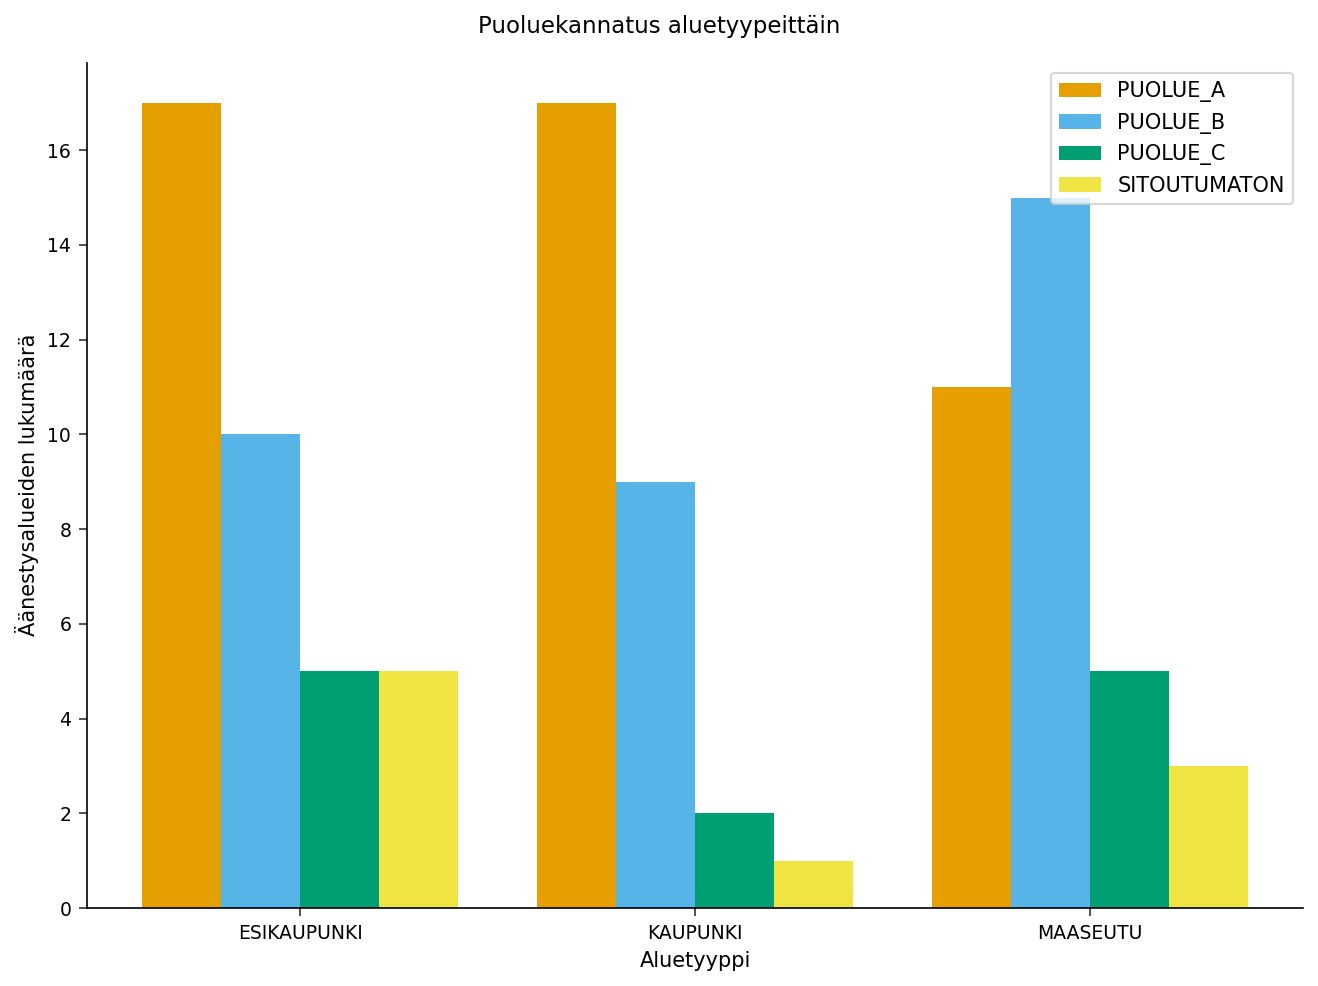

In [3]:
/* --------------------------------------------------------
   Puoluekannatus aluetyypeittäin (äänestysaluemäärät)
   -------------------------------------------------------- */
PROSEDUURI SGPLOT TIEDOT=work.precinct_votes;
    VBAR precinct_type / GROUP=party GROUPDISPLAY=CLUSTER
        STAT=FREKVENSSIT;
    XAXIS NIMIKE='Aluetyyppi';
    YAXIS NIMIKE='Äänestysalueiden lukumäärä';
    OTSIKKO 'Puoluekannatus aluetyypeittäin';
SUORITA;


---

                      Aluetyyppi puolueittain: ristiintaulukointi odotettujen frekvenssien kanssa                       

                                                   The FREQ Procedure

Table of Aluetyyppi by Puolue

Aluetyyppi  |    PUOLUE_A |    PUOLUE_B |    PUOLUE_C |SITOUTUMATON |        Total
------------+-------------+-------------+-------------+-------------+-------------
ESIKAUPUNKI |          17 |          10 |           5 |           5 |           37
            |       17.00 |       10.00 |        5.00 |        5.00 |        37.00
            |       16.65 |       12.58 |        4.44 |        3.33 |             
            |       45.95 |       27.03 |       13.51 |       13.51 |       100.00
            |       37.78 |       29.41 |       41.67 |       55.56 |        37.00
------------+-------------+-------------+-------------+-------------+-------------
KAUPUNKI    |          17 |           9 |           2 |           1 |           29
            |       17.00 |  


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.


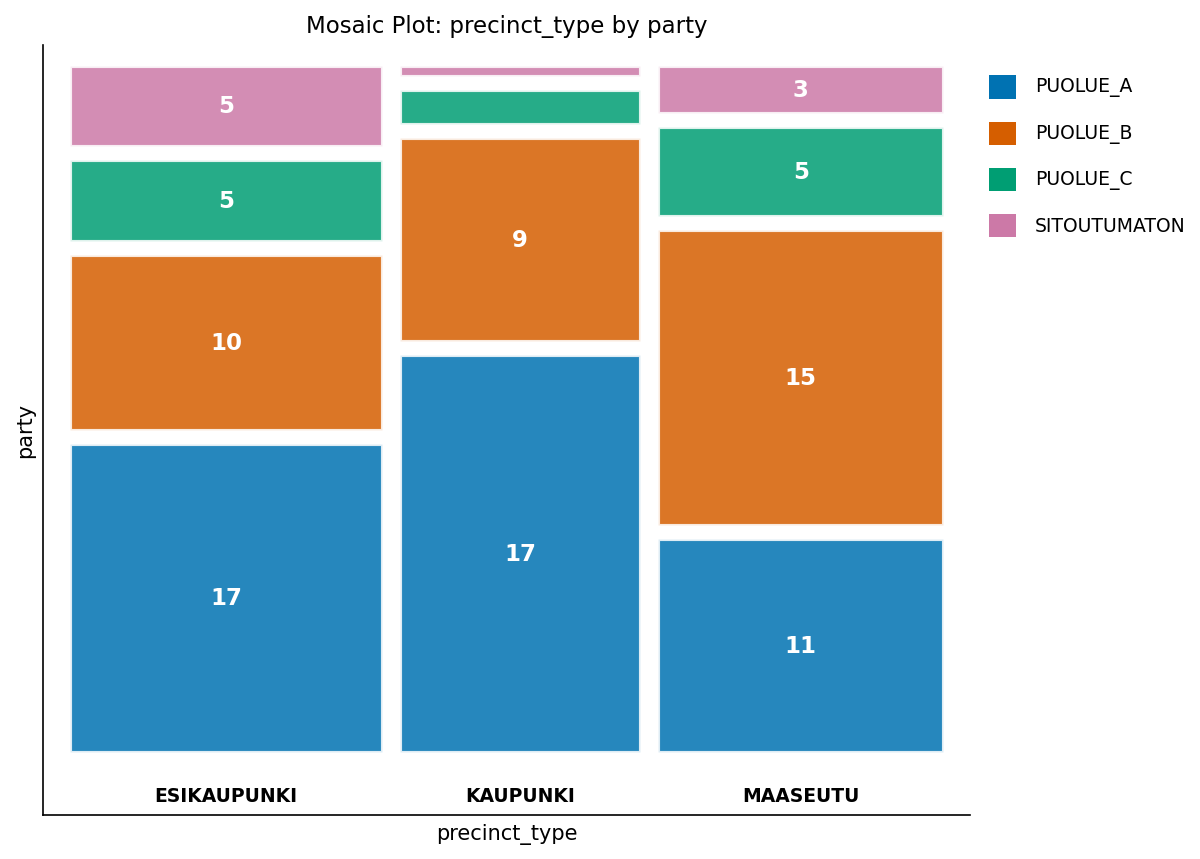

In [4]:
/* --------------------------------------------------------
   Aluetyypin ja puolueen ristiintaulukointi.
   Pyydä ODOTETUT frekvenssit, jotta harvat solut näkyvät,
   sekä asymptoottinen Pearsonin khiin neliö -testi
   yleisestä riippuvuudesta. Huomaa pienet odotetut
   frekvenssit SITOUTUMATON- ja PUOLUE_C-sarakkeissa --
   vihje siitä, että järjestetty, eksakti trenditesti on
   parempi päättelyväline.
   -------------------------------------------------------- */
PROSEDUURI FREKVENSSIT TIEDOT=work.precinct_votes;
    TABLES precinct_type * party / chisq expected;
    NIMIKE precinct_type='Aluetyyppi' party='Puolue';
    OTSIKKO 'Aluetyyppi puolueittain: ristiintaulukointi odotettujen frekvenssien kanssa';
SUORITA;


                       Cochran-Armitagen trenditesti: Puolue A:n kannatus aluetyyppigradientilla                        

                                                   The FREQ Procedure

Table of Aluetyyppijärjestys by Puolue A:n kannatus

Aluetyyppijärjestys  |         0 |         1 |      Total
---------------------+-----------+-----------+-----------
1                    |        12 |        17 |         29
                     |     12.00 |     17.00 |      29.00
                     |     41.38 |     58.62 |     100.00
                     |     21.82 |     37.78 |      29.00
---------------------+-----------+-----------+-----------
2                    |        20 |        17 |         37
                     |     20.00 |     17.00 |      37.00
                     |     54.05 |     45.95 |     100.00
                     |     36.36 |     37.78 |      37.00
---------------------+-----------+-----------+-----------
3                    |        23 |        11 |         34



NOTE: DATA work.precinct_ordinal


NOTE: Read 100 rows from work.precinct_votes.
NOTE: Wrote work.precinct_ordinal (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_type_order_party_a_flag.spec.json
NOTE: PROC FREQ statement used.


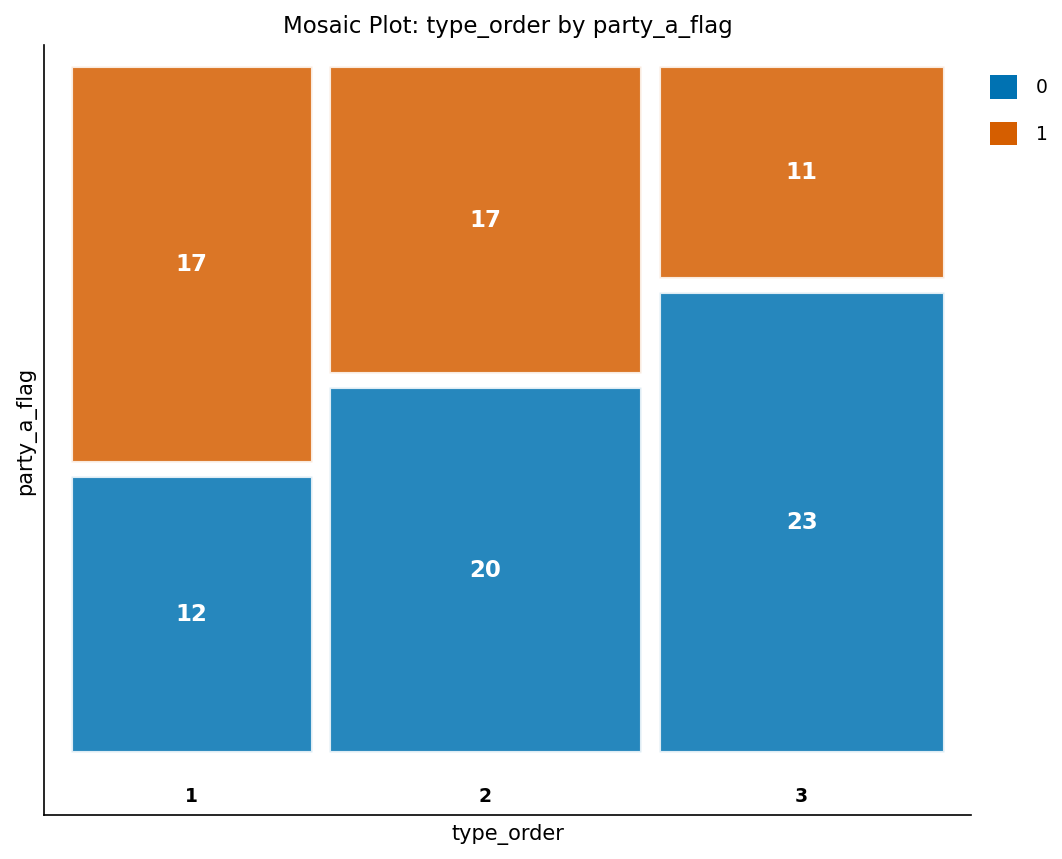

In [5]:
/* --------------------------------------------------------
   Cochran-Armitagen trenditesti. Koodaa aluetyyppi
   järjestysasteikolliseksi pistemääräksi (1=Kaupunki,
   2=Esikaupunki, 3=Maaseutu) ja testaa, näkyykö Puolue A:n
   kannatuksessa monotoninen trendi tätä gradienttia pitkin.
   EXACT TREND pyytää eksaktin p-arvon, mikä on asianmukaista
   pienten solufrekvenssien vuoksi.
   -------------------------------------------------------- */
TIEDOT work.precinct_ordinal;
    ASETA work.precinct_votes;
    /* Järjestysasteikko: 1=Kaupunki, 2=Esikaupunki, 3=Maaseutu */
    JOS precinct_type = 'KAUPUNKI' NIIN type_order = 1;
    MUUTEN JOS precinct_type = 'ESIKAUPUNKI' NIIN type_order = 2;
    MUUTEN type_order = 3;
    /* Binäärinen tulosmuuttuja: Puolue A vs. kaikki muut puolueet */
    party_a_flag = (party = 'PUOLUE_A');
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=work.precinct_ordinal;
    TABLES type_order * party_a_flag / chisq trend;
    EXACT trend;
    NIMIKE type_order='Aluetyyppijärjestys' party_a_flag='Puolue A:n kannatus';
    OTSIKKO 'Cochran-Armitagen trenditesti: Puolue A:n kannatus aluetyyppigradientilla';
SUORITA;


                                          Aluetyyppien jakauma piirikunnittain                                          

                                                   The FREQ Procedure

Table of Piirikunta by Aluetyyppi

Piirikunta |ESIKAUPUNKI |   KAUPUNKI |   MAASEUTU |       Total
-----------+------------+------------+------------+------------
ADAMS      |         10 |          4 |          5 |          19
           |      10.00 |       4.00 |       5.00 |       19.00
           |      52.63 |      21.05 |      26.32 |      100.00
           |      27.03 |      13.79 |      14.71 |       19.00
-----------+------------+------------+------------+------------
HAMILTON   |          7 |          7 |          7 |          21
           |       7.00 |       7.00 |       7.00 |       21.00
           |      33.33 |      33.33 |      33.33 |      100.00
           |      18.92 |      24.14 |      20.59 |       21.00
-----------+------------+------------+------------+------------
JEFF


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_county_name_precinct_type.spec.json
NOTE: PROC FREQ statement used.


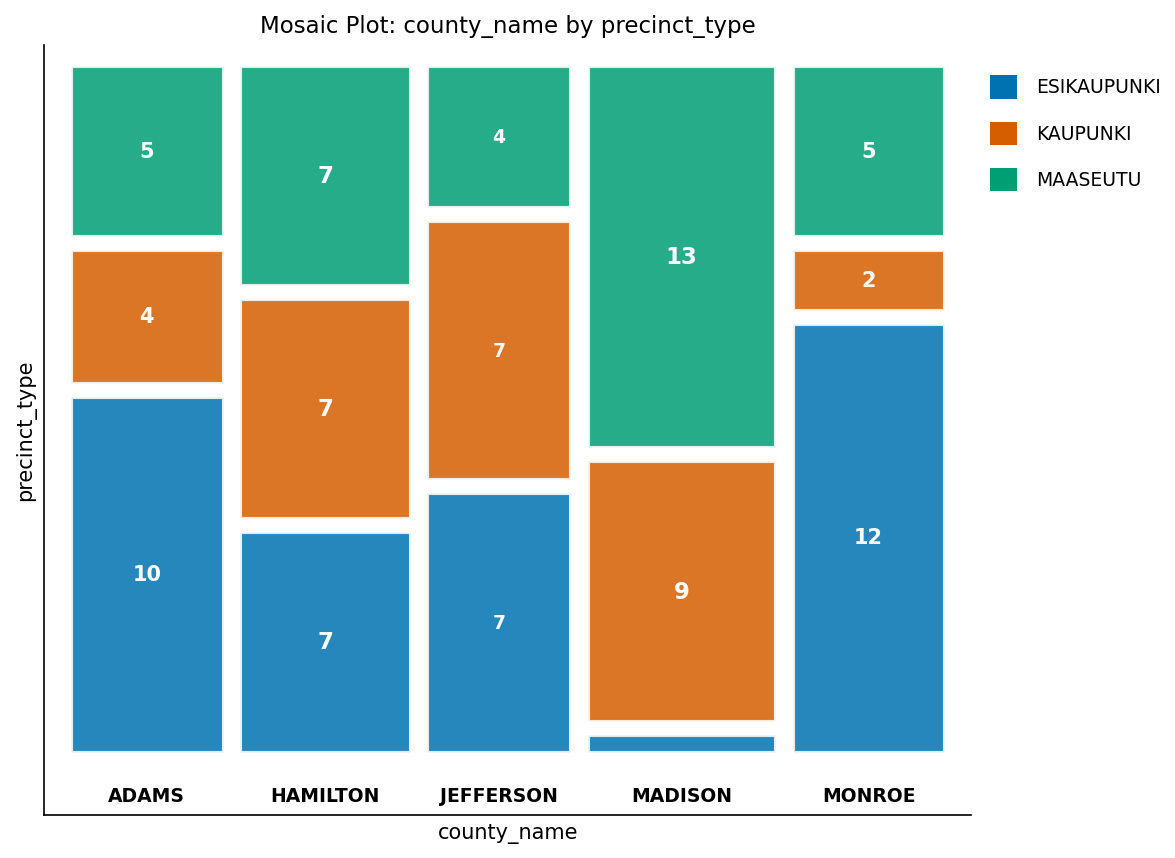

In [6]:
/* --------------------------------------------------------
   Piirikuntatason tarkastelu: miten kaupunki-/esikaupunki-
   /maaseutujakauma vaihtelee viiden piirikunnan kesken.
   Tämä asettaa trenditalouden kontekstiin -- aluetyyppi-
   gradientti on läsnä joka piirikunnassa, mutta sen
   koostumus vaihtelee.
   -------------------------------------------------------- */
PROSEDUURI FREKVENSSIT TIEDOT=work.precinct_votes;
    TABLES county_name * precinct_type / nocum;
    NIMIKE county_name='Piirikunta' precinct_type='Aluetyyppi';
    OTSIKKO 'Aluetyyppien jakauma piirikunnittain';
SUORITA;


---

### Tulkinta

Kaikista 100 äänestysalueesta Puolue A on suurin puolue kokonaisuudessaan
(45 äänestysaluetta), ja sitä seuraavat Puolue B (34), Puolue C (12) sekä
sitoutumattomat (9). Ristiintaulukointi osoittaa, että Puolue A:n osuus
noudattaa selkeää kaupunki-maaseutu-gradienttia: se kattaa 58,6 %
kaupunkialueista, 46,0 % esikaupunkialueista ja 32,4 % maaseutualueista,
kun taas Puolue B liikkuu vastakkaiseen suuntaan nousten 31,0 %:sta
kaupungissa 44,1 %:iin maaseudulla.

Yleinen Pearsonin khiin neliö -testi riippuvuudesta ei ole tilastollisesti
merkitsevä (khiin neliö = 6,78, 6 vapausastetta, p = 0,3418; Cramérin V =
0,18). Tämä tulos on myös hauras: odotettujen frekvenssien näyttö
paljastaa useita soluja alle viiden — esimerkiksi sitoutumattomien
sarakkeessa odotetut frekvenssit ovat 3,06, 3,33 ja 2,61, ja
kaupunkialueiden sitoutumattomia on vain yksi äänestysalue — joten suuren
otoksen khiin neliö -approksimaatio on tässä epäluotettava.

Cochran-Armitagen trenditesti terävöittää kysymystä käyttämällä
järjestysasteikollista kaupunki-esikaupunki-maaseutu-pisteytystä. Se
havaitsee monotonisen laskun Puolue A:n kannatuksessa, jonka yleinen
testi jättää huomaamatta: trendin khiin neliö = 4,38, asymptoottinen
Pr > ChiSq = 0,0363 ja eksakti Pr >= |Z| = 0,0431, merkitsevä
0,05-tasolla. Tämä on analyyttinen hyöty — kohdennettu, eksakti, yhden
vapausasteen testi löytää todellisen suunnatun signaalin, jota harvojen
solujen heikentämä yleinen kuuden vapausasteen riippuvuustesti ei löydä.

Piirikuntatason tarkastelu vahvistaa, että kaupunki-esikaupunki-maaseutu
-jako esiintyy kaikissa viidessä piirikunnassa, vaikka jakauma vaihtelee:
Madison on maaseutupainotteisin (13/23 äänestysaluetta maaseutua), kun
taas Monroe on esikaupunkipainotteisin (12/19). Vaalipiirien
uudelleenjaon vaikutusarviointia varten johtopäätös on, että
rajamuutokset, jotka siirtävät äänestysalueita kaupunki-maaseutu-akselilla,
muuttaisivat mitattavasti puoluejakaumaa, ja että tätä maantieteellistä
trendiä havainnollistaa parhaiten eksakti trenditesti eikä yleinen
khiin neliö -testi.


---

                                          Aluetyyppien jakauma piirikunnittain                                          

                                                   The FREQ Procedure

Table of precinct_type by party

precinct_type |    PUOLUE_A |    PUOLUE_B |    PUOLUE_C |SITOUTUMATON |        Total
--------------+-------------+-------------+-------------+-------------+-------------
ESIKAUPUNKI   |          17 |          10 |           5 |           5 |           37
              |       17.00 |       10.00 |        5.00 |        5.00 |        37.00
              |       45.95 |       27.03 |       13.51 |       13.51 |       100.00
              |       37.78 |       29.41 |       41.67 |       55.56 |        37.00
--------------+-------------+-------------+-------------+-------------+-------------
KAUPUNKI      |          17 |           9 |           2 |           1 |           29
              |       17.00 |        9.00 |        2.00 |        1.00 |        29.00
         


NOTE: PROC FREQ
NOTE: Output dataset work.voting_pattern_summary has 12 observations and 4 variables.
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.voting_pattern_summary outfile=precinct_voting_patterns.csv

NOTE: Exported 12 rows to precinct_voting_patterns.csv.


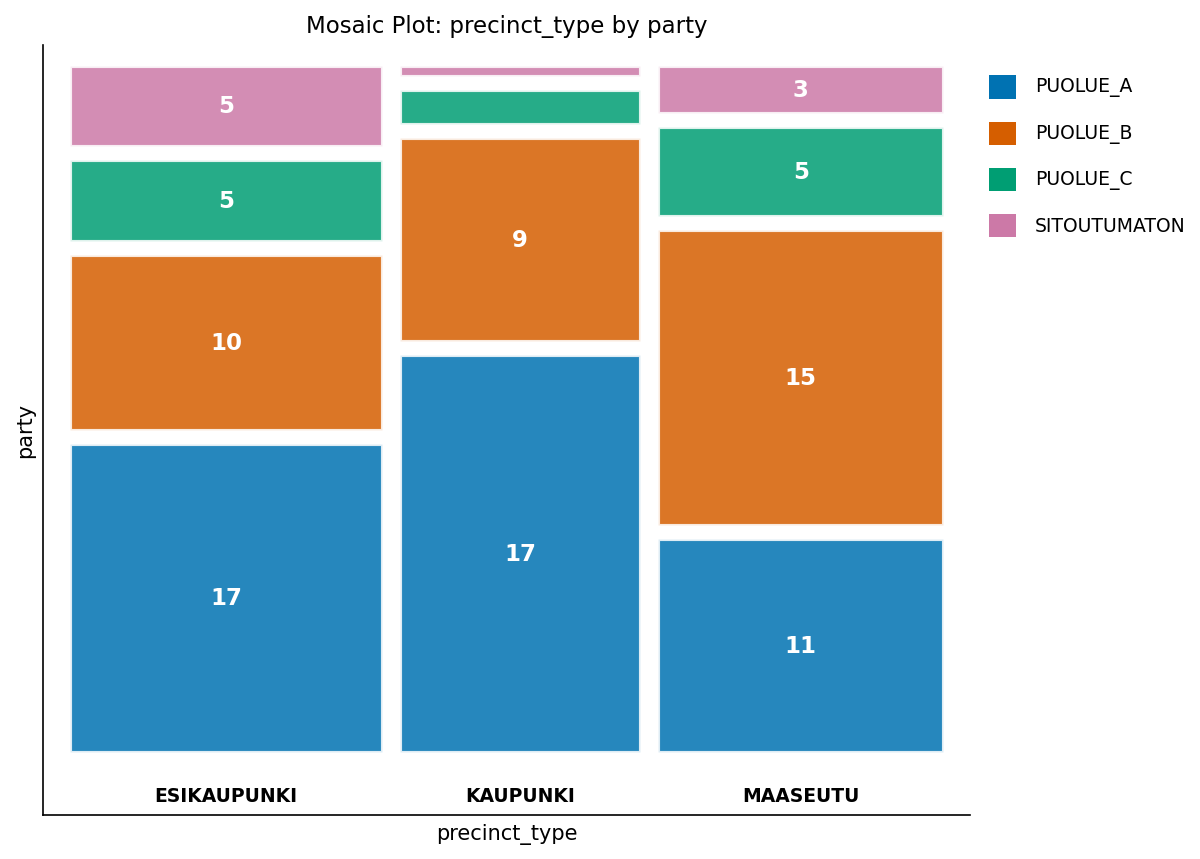

In [7]:
/* --------------------------------------------------------
   Vie aluetyypin ja puolueen yhteenveto vaalipiirien
   uudelleenjaon vaikutusarviointia varten.
   -------------------------------------------------------- */
PROSEDUURI FREKVENSSIT TIEDOT=work.precinct_votes;
    TABLES precinct_type * party / out=work.voting_pattern_summary nocum;
SUORITA;

PROSEDUURI VIE TIEDOT=work.voting_pattern_summary
    OUTFILE='precinct_voting_patterns.csv'
    DBMS=csv REPLACE;
SUORITA;


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Toteutettu <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>-alustalla
</div>
</div>